In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
saitejabandaruin_open_global_workforce_intelligence_2026_path = kagglehub.dataset_download('saitejabandaruin/open-global-workforce-intelligence-2026')

print('Data source import complete.')


100%|██████████| 622k/622k [00:00<00:00, 1.45MB/s]

Extracting files...
Data source import complete.


<img src="https://devra.ai/analyst/notebook/6351/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;">
    <div style="font-size:150%; color:#FEE100"><b>Workforce Intelligence Analysis and Prediction</b></div>
    <div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div>
</div>

This notebook explores job posting data from the US and Global markets for tech roles in 2026. Our curiosity is driven by the idea that trends in salary, location and technology emphasis might reveal useful insights into the workforce of the future. If you find this notebook useful, please consider upvoting it.

## Table of Contents

- [Imports and Configurations](#Imports-and-Configurations)
- [Data Loading](#Data-Loading)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Predictive Modeling](#Predictive-Modeling)
- [Discussion and Conclusion](#Discussion-and-Conclusion)

In [2]:
# Import necessary libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # using Agg backend as required
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # if only plt is imported

import seaborn as sns
import os
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

%matplotlib inline

In [3]:
# Helper to resolve data files dynamically
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# Example usage:
# file_path = resolve_data_file(file_name='usajobs_tech_roles_2026.csv')

## Data Loading

We have two datasets: one for the US tech roles and one representing the global tech market. Both datasets share the same schema. We begin by loading the data and taking a quick look at their structure.

In [4]:
from pathlib import Path

# Load the US dataset
us_file = Path(saitejabandaruin_open_global_workforce_intelligence_2026_path) / 'usajobs_tech_roles_2026.csv'
us_df = pd.read_csv(us_file, encoding='ascii', delimiter=',')
print('US Data Shape:', us_df.shape)
print(us_df.head())

# Load the Global dataset
global_file = Path(saitejabandaruin_open_global_workforce_intelligence_2026_path) / 'global_tech_market_2026.csv'
global_df = pd.read_csv(global_file, encoding='ascii', delimiter=',')
print('Global Data Shape:', global_df.shape)
print(global_df.head())

US Data Shape: (2997, 10)
         job_id                  job_title           company_name  \
0  OGWIP_100000  Machine Learning Engineer          Umbrella Corp   
1  OGWIP_100002             Data Scientist  European Space Agency   
2  OGWIP_100011       Full Stack Developer          Umbrella Corp   
3  OGWIP_100013        Lead Data Scientist       AI Solutions LLC   
4  OGWIP_100031          Backend Developer              CyberDyne   

                 location  salary_min_usd  salary_max_usd  \
0  San Francisco, CA, USA          128065          169396   
1  Amsterdam, Netherlands           85285          127996   
2              London, UK           72939           99091   
3       New York, NY, USA          215001          280274   
4           Remote - APAC           74938           96342   

                               tech_stack   source  \
0     JavaScript, React, Node.js, MongoDB  USAJOBS   
1  Rust, WebAssembly, System Architecture  USAJOBS   
2     JavaScript, React, Node.

## Data Cleaning and Preprocessing

In this section we clean the data, convert date strings to datetime objects, and set up consistent formatting. In some datasets date strings can be tricky to convert if they do not follow a standard format. Here we use pandas' to_datetime with error coercion to handle any inconsistencies.

In [5]:
# Function to preprocess a dataframe
def preprocess_df(df):
    # Convert date_posted from string to datetime. Use errors='coerce' to handle any unexpected formats.
    df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')

    # Create an average salary column for additional analysis
    df['salary_avg'] = (df['salary_min_usd'] + df['salary_max_usd']) / 2

    # It might be interesting to see the length of the job title and description
    df['job_title_length'] = df['job_title'].apply(lambda x: len(str(x)))
    df['description_length'] = df['description'].apply(lambda x: len(str(x)))

    return df

# Preprocess both datasets
us_df = preprocess_df(us_df)
global_df = preprocess_df(global_df)

print('US Data after preprocessing:')
print(us_df.head())

print('Global Data after preprocessing:')
print(global_df.head())

US Data after preprocessing:
         job_id                  job_title           company_name  \
0  OGWIP_100000  Machine Learning Engineer          Umbrella Corp   
1  OGWIP_100002             Data Scientist  European Space Agency   
2  OGWIP_100011       Full Stack Developer          Umbrella Corp   
3  OGWIP_100013        Lead Data Scientist       AI Solutions LLC   
4  OGWIP_100031          Backend Developer              CyberDyne   

                 location  salary_min_usd  salary_max_usd  \
0  San Francisco, CA, USA          128065          169396   
1  Amsterdam, Netherlands           85285          127996   
2              London, UK           72939           99091   
3       New York, NY, USA          215001          280274   
4           Remote - APAC           74938           96342   

                               tech_stack   source  \
0     JavaScript, React, Node.js, MongoDB  USAJOBS   
1  Rust, WebAssembly, System Architecture  USAJOBS   
2     JavaScript, React, No

## Exploratory Data Analysis

We now dive into some visualizations to understand the distribution of data. We include several visualization types including histograms, bar plots, and boxen plots to understand salary distributions, job title lengths, and other features. For numeric correlation analyses, we restrict our attention to numeric columns; however, note that our datasets have only two primary numeric salary columns along with a few engineered ones.

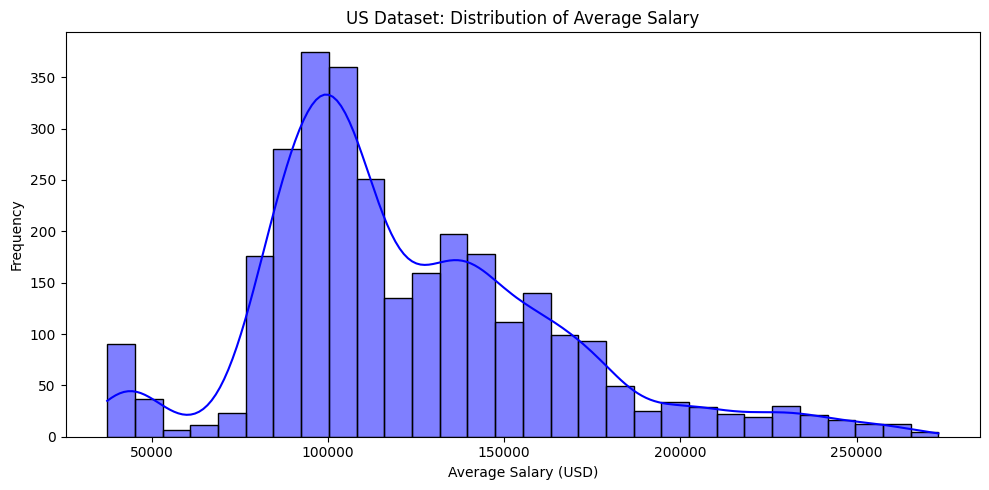

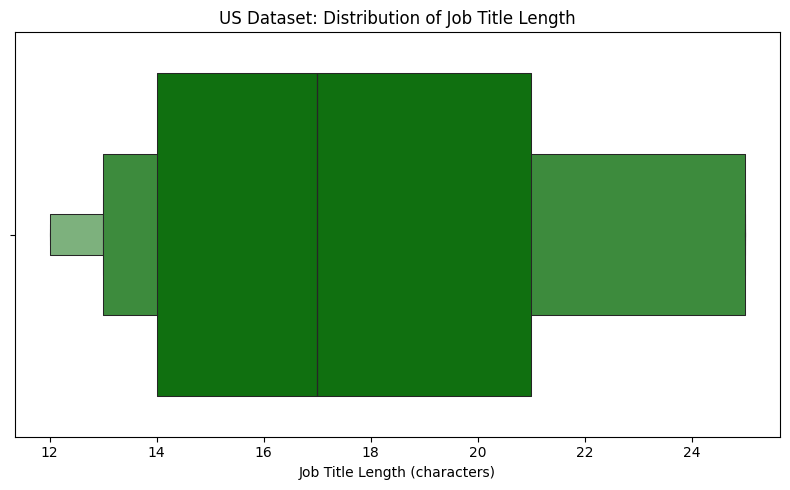

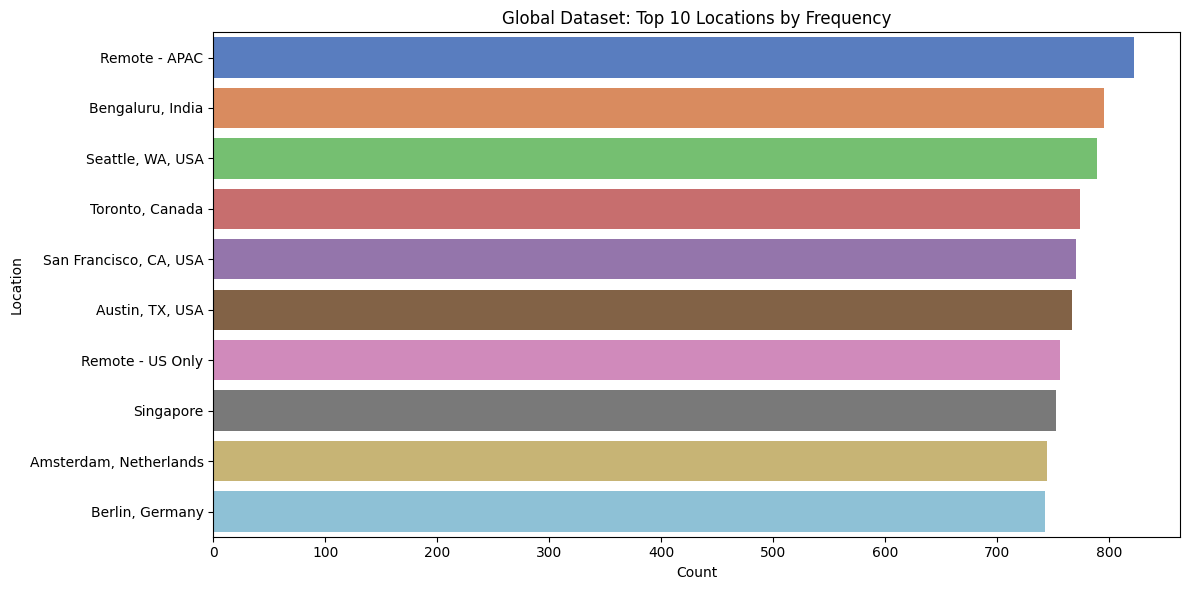

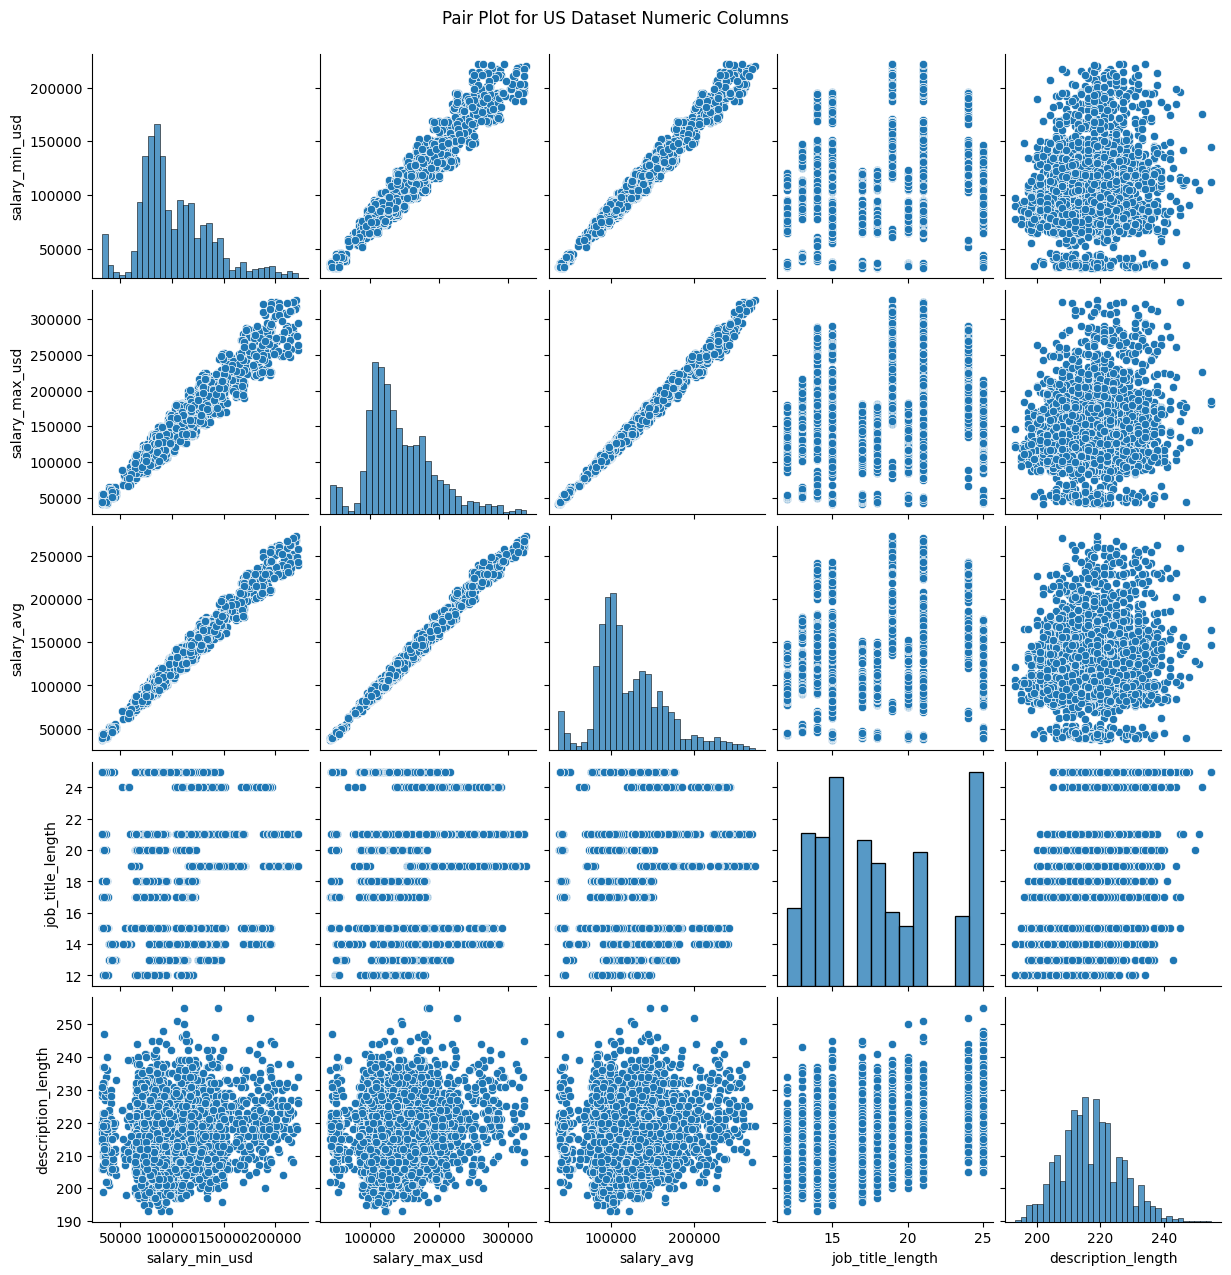

In [6]:
# Histograms for salary distributions
plt.figure(figsize=(10, 5))
sns.histplot(us_df['salary_avg'], kde=True, bins=30, color='blue')
plt.title('US Dataset: Distribution of Average Salary')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Boxen plot for job title length
plt.figure(figsize=(8, 5))
sns.boxenplot(x=us_df['job_title_length'], color='green')
plt.title('US Dataset: Distribution of Job Title Length')
plt.xlabel('Job Title Length (characters)')
plt.tight_layout()
plt.show()

# Countplot for location frequency in the Global dataset (top 10 locations)
plt.figure(figsize=(12, 6))
top_locations = global_df['location'].value_counts().nlargest(10).index
sns.countplot(y='location', data=global_df[global_df['location'].isin(top_locations)], order=top_locations, palette='muted')
plt.title('Global Dataset: Top 10 Locations by Frequency')
plt.xlabel('Count')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

# Pair Plot using numeric fields if four or more numeric columns exist
numeric_cols = ['salary_min_usd', 'salary_max_usd', 'salary_avg', 'job_title_length', 'description_length']
numeric_df = us_df[numeric_cols]
if numeric_df.shape[1] >= 4:
    sns.pairplot(numeric_df)
    plt.suptitle('Pair Plot for US Dataset Numeric Columns', y=1.02)
    plt.show()
else:
    print('Not enough numeric columns for a pairplot.')

## Predictive Modeling

In many job posting datasets, one practical objective is to predict whether a job post offers a high salary or not, which can help in targeting job searches. We create a binary target using the median of the average salary in the US dataset and then train a simple logistic regression model using engineered features such as job title length and description length. In production scenarios, consider more advanced features and models for a deeper analysis.

Logistic Regression Accuracy: 0.56


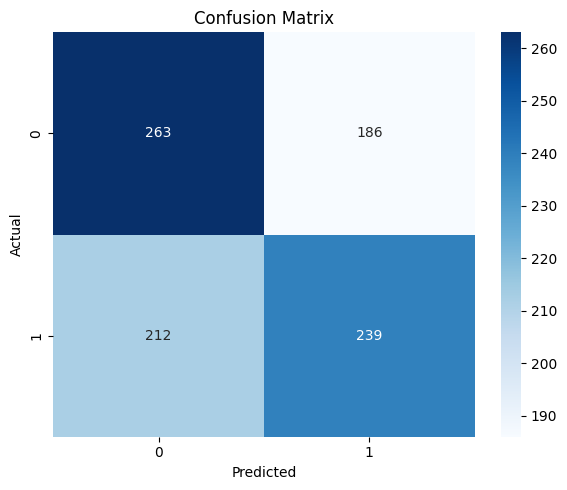

In [7]:
# Create a binary target variable 'high_salary'
median_salary = us_df['salary_avg'].median()
us_df['high_salary'] = (us_df['salary_avg'] > median_salary).astype(int)

# Define features and target
# We use engineered features: job_title_length and description_length
features = ['job_title_length', 'description_length']
target = 'high_salary'

# Split the data into train and test sets
X = us_df[features]
y = us_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Instantiate and train a logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions on test set
y_pred = model.predict(X_test)

# Compute and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Logistic Regression Accuracy: {accuracy:.2f}')

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(y_test, y_pred)
print('Classification Report:\n', report)

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.59      0.57       449
           1       0.56      0.53      0.55       451

    accuracy                           0.56       900
   macro avg       0.56      0.56      0.56       900
weighted avg       0.56      0.56      0.56       900



### Random Forest Classifier

Random Forest Classifier Accuracy: 0.64


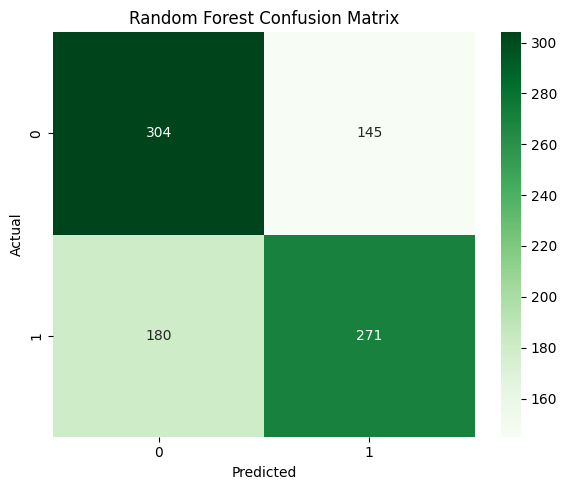

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate and train a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on test set
y_pred_rf = rf_model.predict(X_test)

# Compute and print accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Classifier Accuracy: {rf_accuracy:.2f}')

# Confusion matrix visualization
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import classification_report

# Generate a classification report for Random Forest
report_rf = classification_report(y_test, y_pred_rf)
print('Random Forest Classification Report:\n', report_rf)

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.68      0.65       449
           1       0.65      0.60      0.63       451

    accuracy                           0.64       900
   macro avg       0.64      0.64      0.64       900
weighted avg       0.64      0.64      0.64       900



### Random Forest Classifier with `company_name` feature

In [11]:
from sklearn.preprocessing import OneHotEncoder

# Create a copy of the US dataframe to avoid modifying the original
us_df_encoded = us_df.copy()

# Perform one-hot encoding on 'company_name'
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
company_encoded = encoder.fit_transform(us_df_encoded[['company_name']])
company_df = pd.DataFrame(company_encoded, columns=encoder.get_feature_names_out(['company_name']), index=us_df_encoded.index)

# Concatenate the new one-hot encoded features with the existing numerical features
features_extended = ['job_title_length', 'description_length'] + list(company_df.columns)
X_extended = pd.concat([us_df_encoded[ ['job_title_length', 'description_length']], company_df], axis=1)
y_extended = us_df_encoded[target]

# Split the data into train and test sets with the extended features
X_train_extended, X_test_extended, y_train_extended, y_test_extended = train_test_split(X_extended, y_extended, test_size=0.3, random_state=42)

print(f'Shape of X_train_extended: {X_train_extended.shape}')
print(f'Shape of X_test_extended: {X_test_extended.shape}')

Shape of X_train_extended: (2097, 19)
Shape of X_test_extended: (900, 19)


Random Forest Classifier (with company_name) Accuracy: 0.66


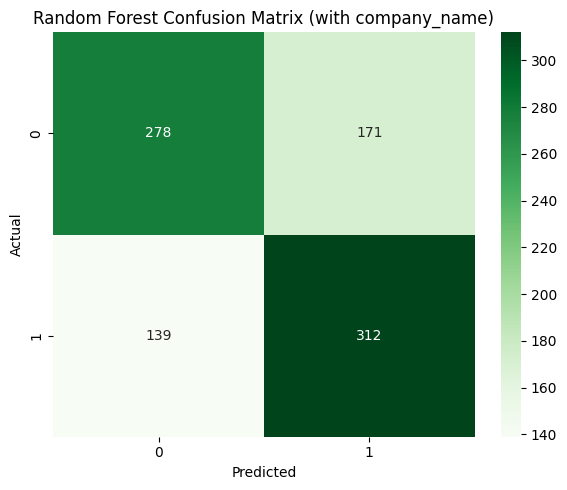

In [12]:
# Instantiate and train a Random Forest Classifier with extended features
rf_model_extended = RandomForestClassifier(random_state=42)
rf_model_extended.fit(X_train_extended, y_train_extended)

# Make predictions on test set
y_pred_rf_extended = rf_model_extended.predict(X_test_extended)

# Compute and print accuracy
rf_accuracy_extended = accuracy_score(y_test_extended, y_pred_rf_extended)
print(f'Random Forest Classifier (with company_name) Accuracy: {rf_accuracy_extended:.2f}')

# Confusion matrix visualization
cm_rf_extended = confusion_matrix(y_test_extended, y_pred_rf_extended)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_extended, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix (with company_name)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import classification_report

# Generate a classification report for Random Forest with extended features
report_rf_extended = classification_report(y_test_extended, y_pred_rf_extended)
print('Random Forest Classification Report (with company_name):\n', report_rf_extended)

Random Forest Classification Report (with company_name):
               precision    recall  f1-score   support

           0       0.67      0.62      0.64       449
           1       0.65      0.69      0.67       451

    accuracy                           0.66       900
   macro avg       0.66      0.66      0.66       900
weighted avg       0.66      0.66      0.66       900



### Feature Importance of Random Forest Model (with `company_name`)

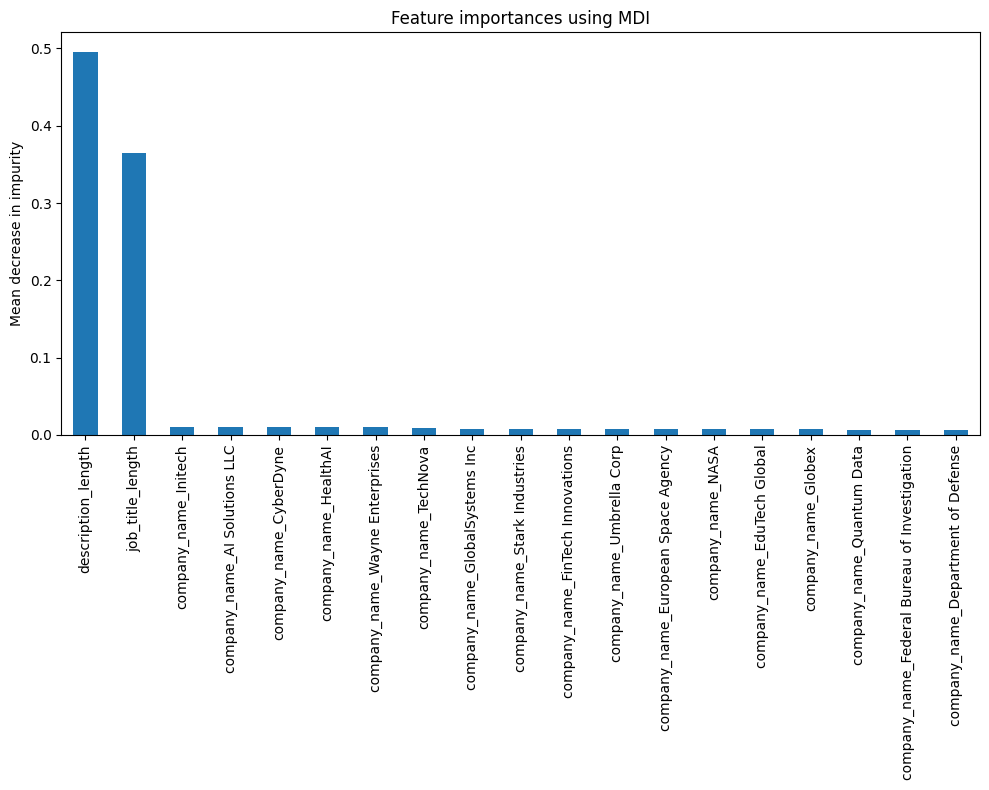

In [14]:
importances = rf_model_extended.feature_importances_
feature_names = X_train_extended.columns

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 8))
forest_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

### Hyperparameter Tuning with GridSearchCV for Random Forest

Starting GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV complete.
Best parameters found: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Tuned Random Forest Classifier Accuracy: 0.68


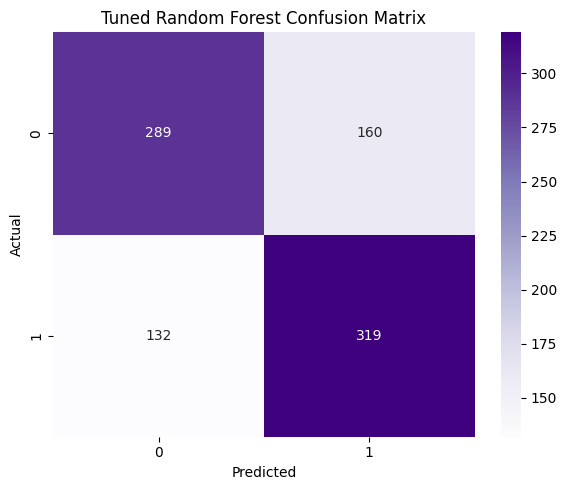

In [15]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
# 'cv=5' means 5-fold cross-validation
# 'verbose=2' provides more detailed output during the process
# 'n_jobs=-1' uses all available processors
grid_search = GridSearchCV(estimator=rf_model_extended, param_grid=param_grid, cv=5, verbose=2, n_jobs=-1)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV...")
grid_search.fit(X_train_extended, y_train_extended)
print("GridSearchCV complete.")

# Print the best parameters found
print(f"Best parameters found: {grid_search.best_params_}")

# Get the best model
best_rf_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_best_rf = best_rf_model.predict(X_test_extended)

# Evaluate the best model
best_rf_accuracy = accuracy_score(y_test_extended, y_pred_best_rf)
print(f'Tuned Random Forest Classifier Accuracy: {best_rf_accuracy:.2f}')

# Confusion matrix visualization for the tuned model
cm_best_rf = confusion_matrix(y_test_extended, y_pred_best_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='Purples')
plt.title('Tuned Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import classification_report

# Generate a classification report for the tuned Random Forest model
report_best_rf = classification_report(y_test_extended, y_pred_best_rf)
print('Tuned Random Forest Classification Report:\n', report_best_rf)

Tuned Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.64      0.66       449
           1       0.67      0.71      0.69       451

    accuracy                           0.68       900
   macro avg       0.68      0.68      0.68       900
weighted avg       0.68      0.68      0.68       900



### Random Forest Classifier with `company_name` and `location` features

In [17]:
from sklearn.preprocessing import OneHotEncoder

# Create a copy of the US dataframe to avoid modifying the original
us_df_all_encoded = us_df.copy()

# Perform one-hot encoding on 'company_name'
encoder_company = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
company_encoded_all = encoder_company.fit_transform(us_df_all_encoded[['company_name']])
company_df_all = pd.DataFrame(company_encoded_all, columns=encoder_company.get_feature_names_out(['company_name']), index=us_df_all_encoded.index)

# Perform one-hot encoding on 'location'
encoder_location = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
location_encoded = encoder_location.fit_transform(us_df_all_encoded[['location']])
location_df = pd.DataFrame(location_encoded, columns=encoder_location.get_feature_names_out(['location']), index=us_df_all_encoded.index)

# Concatenate all features: numerical, company_name one-hot, and location one-hot
X_all_extended = pd.concat([
    us_df_all_encoded[['job_title_length', 'description_length']],
    company_df_all,
    location_df
], axis=1)
y_all_extended = us_df_all_encoded[target]

# Split the data into train and test sets with the fully extended features
X_train_all_extended, X_test_all_extended, y_train_all_extended, y_test_all_extended = train_test_split(X_all_extended, y_all_extended, test_size=0.3, random_state=42)

print(f'Shape of X_train_all_extended: {X_train_all_extended.shape}')
print(f'Shape of X_test_all_extended: {X_test_all_extended.shape}')

Shape of X_train_all_extended: (2097, 35)
Shape of X_test_all_extended: (900, 35)


Random Forest Classifier (with company_name and location) Accuracy: 0.80


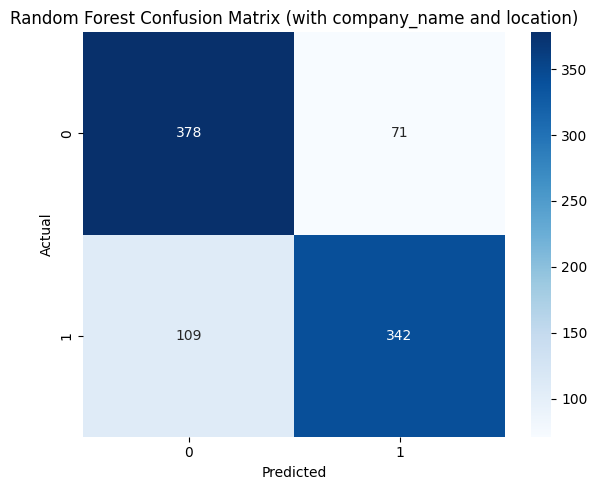

In [18]:
# Instantiate and train a Random Forest Classifier with all extended features
rf_model_all_extended = RandomForestClassifier(random_state=42)
rf_model_all_extended.fit(X_train_all_extended, y_train_all_extended)

# Make predictions on test set
y_pred_rf_all_extended = rf_model_all_extended.predict(X_test_all_extended)

# Compute and print accuracy
rf_accuracy_all_extended = accuracy_score(y_test_all_extended, y_pred_rf_all_extended)
print(f'Random Forest Classifier (with company_name and location) Accuracy: {rf_accuracy_all_extended:.2f}')

# Confusion matrix visualization
cm_rf_all_extended = confusion_matrix(y_test_all_extended, y_pred_rf_all_extended)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_all_extended, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix (with company_name and location)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import classification_report

# Generate a classification report for Random Forest with all extended features
report_rf_all_extended = classification_report(y_test_all_extended, y_pred_rf_all_extended)
print('Random Forest Classification Report (with company_name and location):\n', report_rf_all_extended)

Random Forest Classification Report (with company_name and location):
               precision    recall  f1-score   support

           0       0.78      0.84      0.81       449
           1       0.83      0.76      0.79       451

    accuracy                           0.80       900
   macro avg       0.80      0.80      0.80       900
weighted avg       0.80      0.80      0.80       900



### Feature Importance of Random Forest Model (with `company_name` and `location`)

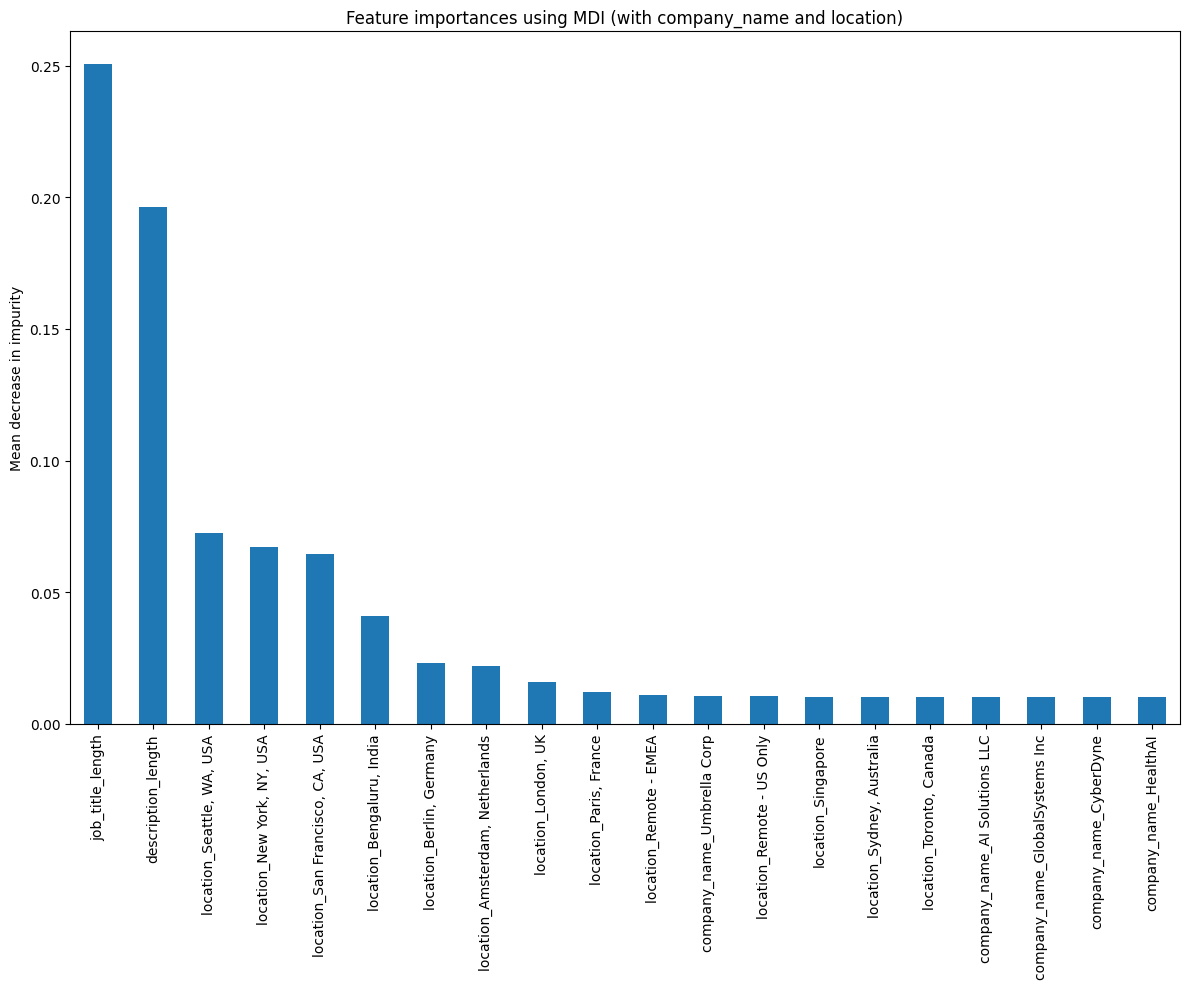

In [20]:
importances_all = rf_model_all_extended.feature_importances_
feature_names_all = X_train_all_extended.columns

forest_importances_all = pd.Series(importances_all, index=feature_names_all)

fig, ax = plt.subplots(figsize=(12, 10))
forest_importances_all.sort_values(ascending=False).head(20).plot.bar(ax=ax) # Display top 20 for readability
ax.set_title("Feature importances using MDI (with company_name and location)")
ax.set_ylabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

### Hyperparameter Tuning with GridSearchCV for Random Forest (with `company_name` and `location`)

Starting GridSearchCV for model with all extended features...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV complete.
Best parameters found: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Tuned Random Forest Classifier (with company_name and location) Accuracy: 0.81


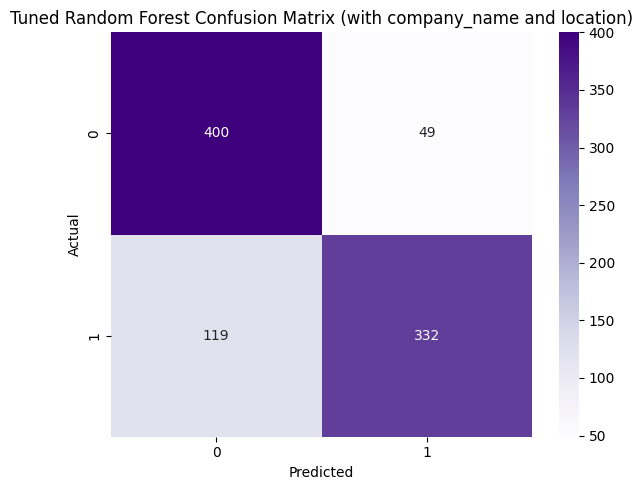

In [21]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid_all = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
# 'cv=5' means 5-fold cross-validation
# 'verbose=2' provides more detailed output during the process
# 'n_jobs=-1' uses all available processors
grid_search_all = GridSearchCV(estimator=rf_model_all_extended, param_grid=param_grid_all, cv=5, verbose=2, n_jobs=-1)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV for model with all extended features...")
grid_search_all.fit(X_train_all_extended, y_train_all_extended)
print("GridSearchCV complete.")

# Print the best parameters found
print(f"Best parameters found: {grid_search_all.best_params_}")

# Get the best model
best_rf_model_all = grid_search_all.best_estimator_

# Make predictions with the best model
y_pred_best_rf_all = best_rf_model_all.predict(X_test_all_extended)

# Evaluate the best model
best_rf_accuracy_all = accuracy_score(y_test_all_extended, y_pred_best_rf_all)
print(f'Tuned Random Forest Classifier (with company_name and location) Accuracy: {best_rf_accuracy_all:.2f}')

# Confusion matrix visualization for the tuned model
cm_best_rf_all = confusion_matrix(y_test_all_extended, y_pred_best_rf_all)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_rf_all, annot=True, fmt='d', cmap='Purples')
plt.title('Tuned Random Forest Confusion Matrix (with company_name and location)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import classification_report

# Generate a classification report for the tuned Random Forest model
report_best_rf_all = classification_report(y_test_all_extended, y_pred_best_rf_all)
print('Tuned Random Forest Classification Report (with company_name and location):\n', report_best_rf_all)

Tuned Random Forest Classification Report (with company_name and location):
               precision    recall  f1-score   support

           0       0.77      0.89      0.83       449
           1       0.87      0.74      0.80       451

    accuracy                           0.81       900
   macro avg       0.82      0.81      0.81       900
weighted avg       0.82      0.81      0.81       900



### Feature Importance of Tuned Random Forest Model (with `company_name` and `location`)

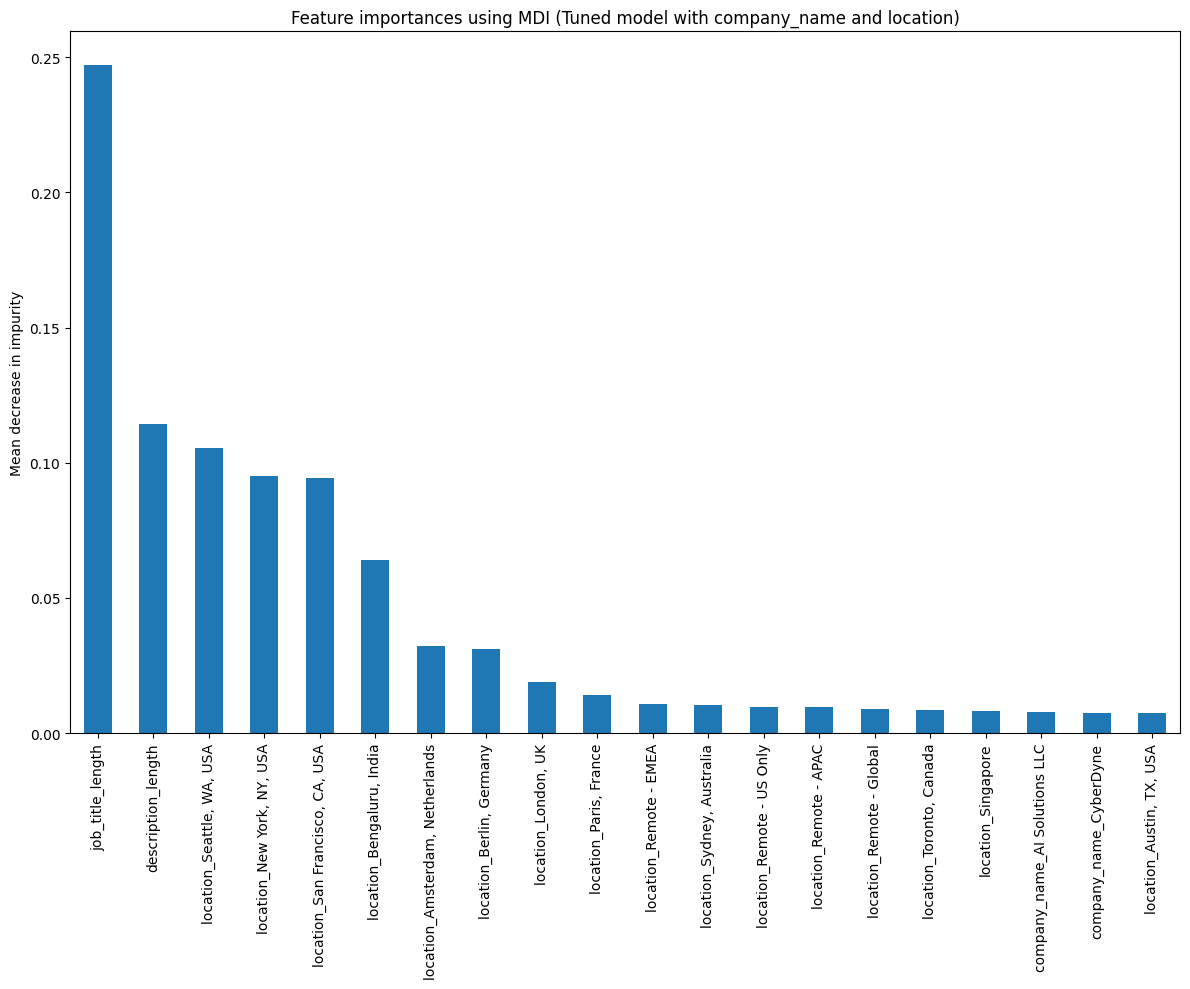

In [23]:
importances_tuned_all = best_rf_model_all.feature_importances_
feature_names_tuned_all = X_train_all_extended.columns

forest_importances_tuned_all = pd.Series(importances_tuned_all, index=feature_names_tuned_all)

fig, ax = plt.subplots(figsize=(12, 10))
forest_importances_tuned_all.sort_values(ascending=False).head(20).plot.bar(ax=ax) # Display top 20 for readability
ax.set_title("Feature importances using MDI (Tuned model with company_name and location)")
ax.set_ylabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

### Comparison of Feature Importance (Untuned vs. Tuned Model)

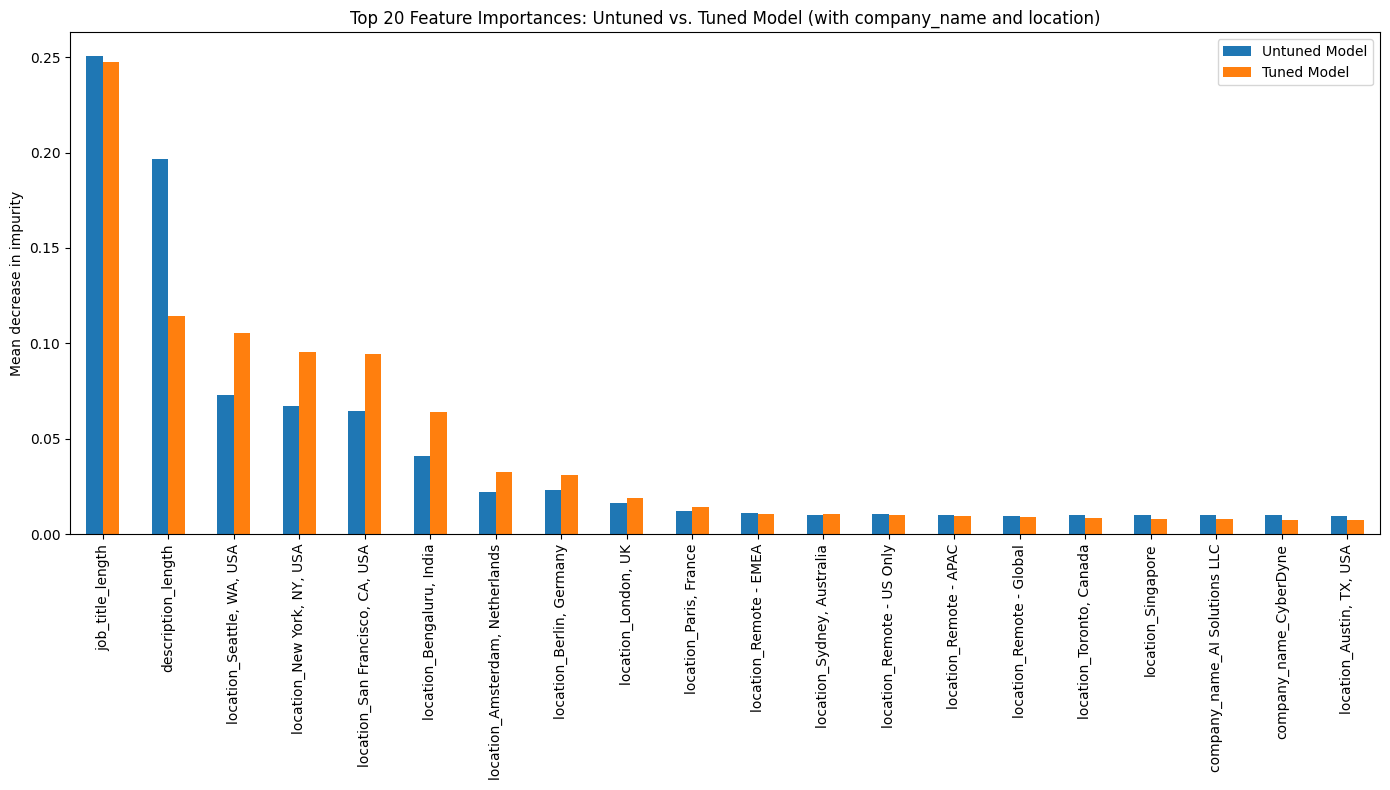

In [24]:
# Combine and sort feature importances for comparison
combined_importances = pd.DataFrame({
    'Untuned Model': forest_importances_all,
    'Tuned Model': forest_importances_tuned_all
})

# Sort by the tuned model's importances (or untuned for consistent view if desired)
combined_importances_sorted = combined_importances.sort_values(by='Tuned Model', ascending=False).head(20)

# Plotting side-by-side bar chart for comparison
fig, ax = plt.subplots(figsize=(14, 8))
combined_importances_sorted.plot.bar(ax=ax)
ax.set_title("Top 20 Feature Importances: Untuned vs. Tuned Model (with company_name and location)")
ax.set_ylabel("Mean decrease in impurity")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Cross-Validation to Assess Model Stability

### Comparison of Performance Metrics: Untuned vs. Tuned Random Forest Models

Let's review the accuracy and classification reports for both the untuned and tuned Random Forest models that incorporate `company_name` and `location` features.

In [32]:
print(f"Untuned Random Forest Classifier Accuracy (with company_name and location): {rf_accuracy_all_extended:.2f}")
print('Untuned Random Forest Classification Report (with company_name and location):\n', report_rf_all_extended)

print(f"\nTuned Random Forest Classifier Accuracy (with company_name and location): {best_rf_accuracy_all:.2f}")
print('Tuned Random Forest Classification Report (with company_name and location):\n', report_best_rf_all)

Untuned Random Forest Classifier Accuracy (with company_name and location): 0.80
Untuned Random Forest Classification Report (with company_name and location):
               precision    recall  f1-score   support

           0       0.78      0.84      0.81       449
           1       0.83      0.76      0.79       451

    accuracy                           0.80       900
   macro avg       0.80      0.80      0.80       900
weighted avg       0.80      0.80      0.80       900


Tuned Random Forest Classifier Accuracy (with company_name and location): 0.81
Tuned Random Forest Classification Report (with company_name and location):
               precision    recall  f1-score   support

           0       0.77      0.89      0.83       449
           1       0.87      0.74      0.80       451

    accuracy                           0.81       900
   macro avg       0.82      0.81      0.81       900
weighted avg       0.82      0.81      0.81       900



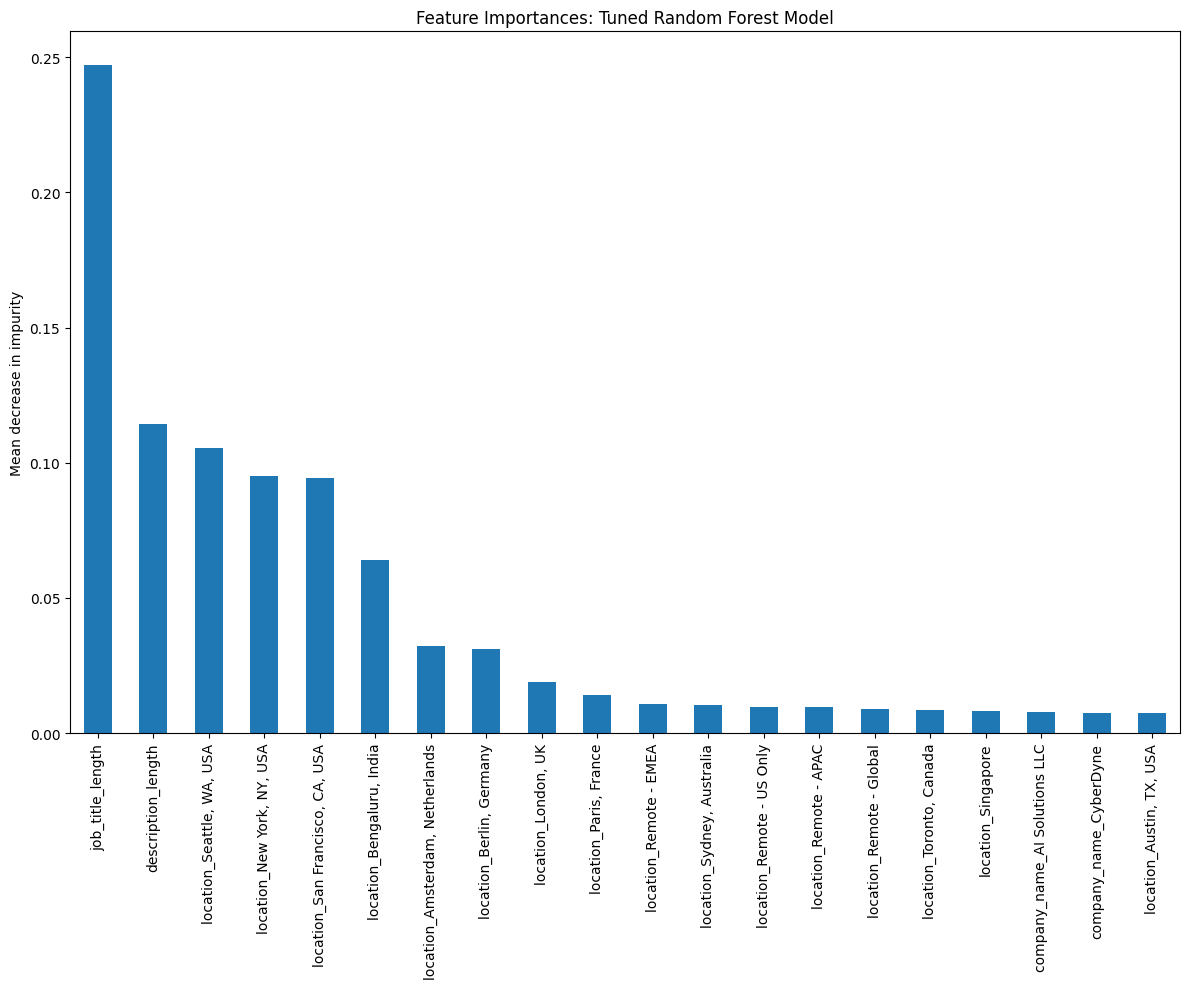

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# The feature importances for the tuned model are in `forest_importances_tuned_all`
# The feature names are in `X_train_all_extended.columns`

forest_importances_tuned_all = pd.Series(best_rf_model_all.feature_importances_, index=X_train_all_extended.columns)

fig, ax = plt.subplots(figsize=(12, 10))
forest_importances_tuned_all.sort_values(ascending=False).head(20).plot.bar(ax=ax)
ax.set_title("Feature Importances: Tuned Random Forest Model")
ax.set_ylabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

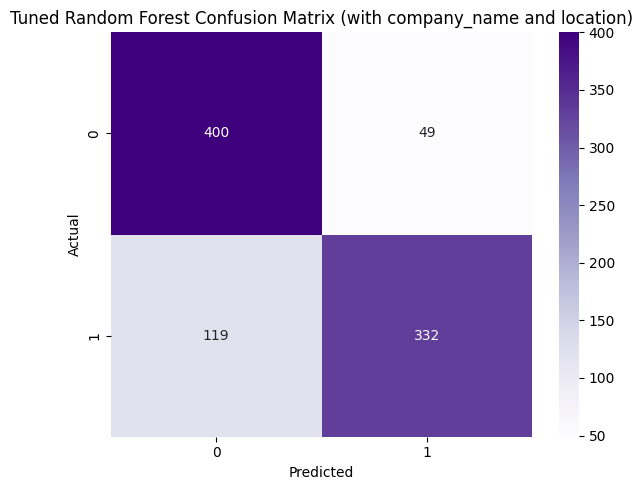

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# The confusion matrix for the final tuned model is stored in `cm_best_rf_all`
# The predictions are in `y_pred_best_rf_all` and the true labels in `y_test_all_extended`

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_rf_all, annot=True, fmt='d', cmap='Purples')
plt.title('Tuned Random Forest Confusion Matrix (with company_name and location)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [25]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on the best-tuned model with all extended features
cv_scores = cross_val_score(best_rf_model_all, X_all_extended, y_all_extended, cv=5, scoring='accuracy', n_jobs=-1)

print(f"Cross-validation accuracies: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.2f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.2f}")

Cross-validation accuracies: [0.80333333 0.81833333 0.84808013 0.81803005 0.8263773 ]
Mean cross-validation accuracy: 0.82
Standard deviation of cross-validation accuracy: 0.01


### Analyzing Misclassified Instances (False Positives and False Negatives)

In [35]:
# Identify False Positives (Actual 0, Predicted 1)
false_positives_mask = (y_test_all_extended == 0) & (y_pred_best_rf_all == 1)
false_positives = X_test_all_extended[false_positives_mask]

print(f"Number of False Positives: {len(false_positives)}")
print("\nSample of False Positives:")
display(us_df.loc[false_positives.index].head())

# You can further analyze these instances, e.g., by checking their original features from us_df


Number of False Positives: 49

Sample of False Positives:


,job_id,job_title,company_name,location,salary_min_usd,salary_max_usd,tech_stack,source,description,date_posted,salary_avg,job_title_length,description_length,high_salary
460,OGWIP_102467,Technical Program Manager,HealthAI,Remote - EMEA,77153,110778,"Python, Pandas, Scikit-Learn, AWS",USAJOBS,"We are HealthAI, looking for a Technical Progr...",2026-08-04 18:00:00,93965.5,25,217,0
2884,OGWIP_114409,Data Engineer,AI Solutions LLC,Remote - Global,87069,116310,"JavaScript, React, Node.js, MongoDB",USAJOBS,"We are AI Solutions LLC, looking for a Data En...",2026-08-03 14:00:00,101689.5,13,217,0
2159,OGWIP_110961,AI Researcher,Wayne Enterprises,Remote - EMEA,87264,117696,"Go, Kubernetes, Docker, GCP",USAJOBS,"We are Wayne Enterprises, looking for a AI Res...",2026-08-01 20:00:00,102480.0,13,208,0
2859,OGWIP_114321,Cybersecurity Analyst,Globex,"Paris, France",90999,112397,"JavaScript, React, Node.js, MongoDB",USAJOBS,"We are Globex, looking for a Cybersecurity Ana...",2026-08-02 17:00:00,101698.0,21,213,0
2809,OGWIP_114028,Cybersecurity Analyst,CyberDyne,"Austin, TX, USA",84537,131749,"Java, Spring Boot, Kafka, PostgreSQL",USAJOBS,"We are CyberDyne, looking for a Cybersecurity ...",2026-08-03 12:00:00,108143.0,21,219,0


In [36]:
# Identify False Negatives (Actual 1, Predicted 0)
false_negatives_mask = (y_test_all_extended == 1) & (y_pred_best_rf_all == 0)
false_negatives = X_test_all_extended[false_negatives_mask]

print(f"Number of False Negatives: {len(false_negatives)}")
print("\nSample of False Negatives:")
display(us_df.loc[false_negatives.index].head())

# Similar to false positives, you can inspect these instances further


Number of False Negatives: 119

Sample of False Negatives:


,job_id,job_title,company_name,location,salary_min_usd,salary_max_usd,tech_stack,source,description,date_posted,salary_avg,job_title_length,description_length,high_salary
2937,OGWIP_114675,Cloud Architect,EduTech Global,Remote - APAC,129345,177010,"Rust, WebAssembly, System Architecture",USAJOBS,"We are EduTech Global, looking for a Cloud Arc...",2026-08-02 05:00:00,153177.5,15,219,1
2295,OGWIP_111605,Lead Data Scientist,Initech,"Amsterdam, Netherlands",134615,171464,"Python, Airflow, Snowflake, dbt",USAJOBS,"We are Initech, looking for a Lead Data Scient...",2026-08-01 10:00:00,153039.5,19,218,1
1487,OGWIP_107558,Machine Learning Engineer,FinTech Innovations,"Paris, France",98718,155870,"Python, Pandas, Scikit-Learn, AWS",USAJOBS,"We are FinTech Innovations, looking for a Mach...",2026-08-02 23:00:00,127294.0,25,228,1
2467,OGWIP_112434,Senior Software Engineer,European Space Agency,"London, UK",119641,136945,"Python, Pandas, Scikit-Learn, AWS",USAJOBS,"We are European Space Agency, looking for a Se...",2026-08-01 01:00:00,128293.0,24,227,1
506,OGWIP_102659,Machine Learning Engineer,FinTech Innovations,Remote - US Only,99990,133017,"TypeScript, Angular, Firebase",USAJOBS,"We are FinTech Innovations, looking for a Mach...",2026-08-04 08:00:00,116503.5,25,227,1


### Distribution of `description_length` for Misclassified Instances

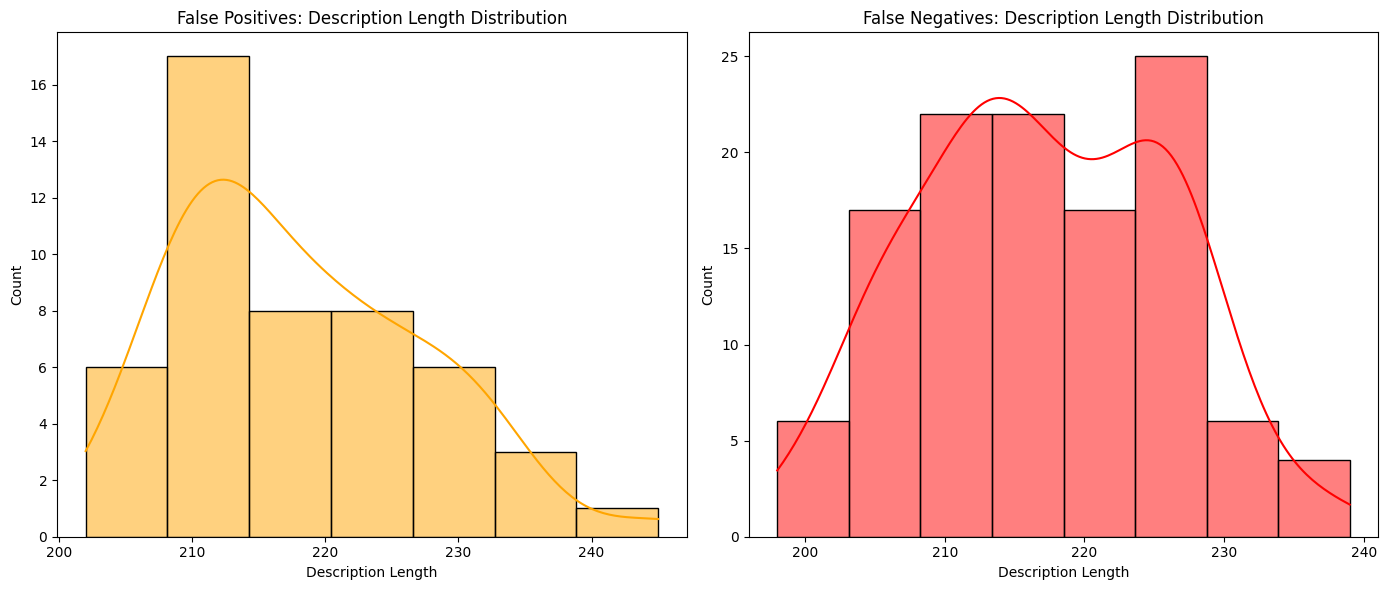

In [37]:
plt.figure(figsize=(14, 6))

# Distribution for False Positives
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(us_df.loc[false_positives.index]['description_length'], kde=True, color='orange')
plt.title('False Positives: Description Length Distribution')
plt.xlabel('Description Length')
plt.ylabel('Count')

# Distribution for False Negatives
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(us_df.loc[false_negatives.index]['description_length'], kde=True, color='red')
plt.title('False Negatives: Description Length Distribution')
plt.xlabel('Description Length')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Mean `description_length` for Misclassified vs. Correctly Classified Instances

In [38]:
# Identify True Positives (Actual 1, Predicted 1)
true_positives_mask = (y_test_all_extended == 1) & (y_pred_best_rf_all == 1)
true_positives = us_df.loc[X_test_all_extended[true_positives_mask].index]

# Identify True Negatives (Actual 0, Predicted 0)
true_negatives_mask = (y_test_all_extended == 0) & (y_pred_best_rf_all == 0)
true_negatives = us_df.loc[X_test_all_extended[true_negatives_mask].index]

# False Positives and False Negatives are already defined in previous cells
# false_positives = us_df.loc[X_test_all_extended[false_positives_mask].index]
# false_negatives = us_df.loc[X_test_all_extended[false_negatives_mask].index]

print(f"Mean description_length for True Positives: {true_positives['description_length'].mean():.2f}")
print(f"Mean description_length for True Negatives: {true_negatives['description_length'].mean():.2f}")
print(f"Mean description_length for False Positives: {us_df.loc[false_positives.index]['description_length'].mean():.2f}")
print(f"Mean description_length for False Negatives: {us_df.loc[false_negatives.index]['description_length'].mean():.2f}")


Mean description_length for True Positives: 218.75
Mean description_length for True Negatives: 216.04
Mean description_length for False Positives: 218.04
Mean description_length for False Negatives: 217.13


### Feature Importance Analysis for Misclassified Instances

In [39]:
# Get the top N most important features from the tuned model
top_n_features = 10
top_features = forest_importances_tuned_all.sort_values(ascending=False).head(top_n_features).index.tolist()

print(f"Top {top_n_features} features by importance:\n{top_features}")

print("\n--- Sample of False Positives with Top Features ---")
display(X_test_all_extended[false_positives_mask][top_features].head())

print("\n--- Sample of False Negatives with Top Features ---")
display(X_test_all_extended[false_negatives_mask][top_features].head())

Top 10 features by importance:
['job_title_length', 'description_length', 'location_Seattle, WA, USA', 'location_New York, NY, USA', 'location_San Francisco, CA, USA', 'location_Bengaluru, India', 'location_Amsterdam, Netherlands', 'location_Berlin, Germany', 'location_London, UK', 'location_Paris, France']

--- Sample of False Positives with Top Features ---


,job_title_length,description_length,"location_Seattle, WA, USA","location_New York, NY, USA","location_San Francisco, CA, USA","location_Bengaluru, India","location_Amsterdam, Netherlands","location_Berlin, Germany","location_London, UK","location_Paris, France"
460,25,217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2884,13,217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2159,13,208,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2859,21,213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2809,21,219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



--- Sample of False Negatives with Top Features ---


,job_title_length,description_length,"location_Seattle, WA, USA","location_New York, NY, USA","location_San Francisco, CA, USA","location_Bengaluru, India","location_Amsterdam, Netherlands","location_Berlin, Germany","location_London, UK","location_Paris, France"
2937,15,219,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2295,19,218,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1487,25,228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2467,24,227,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
506,25,227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Feature Distributions for Misclassified vs. Correctly Classified Instances

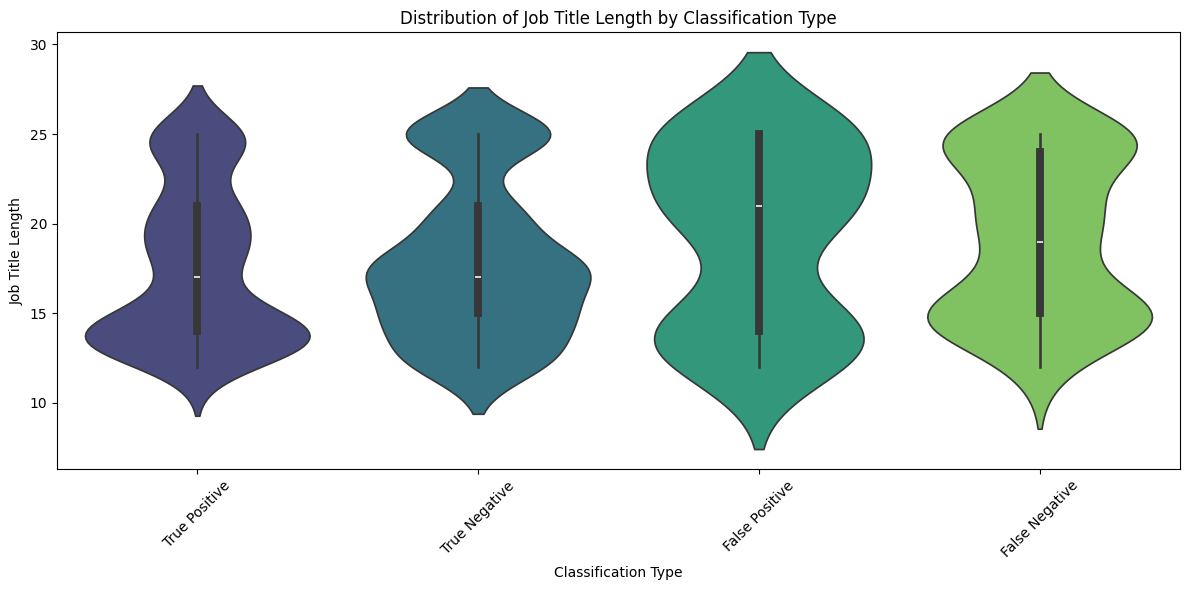

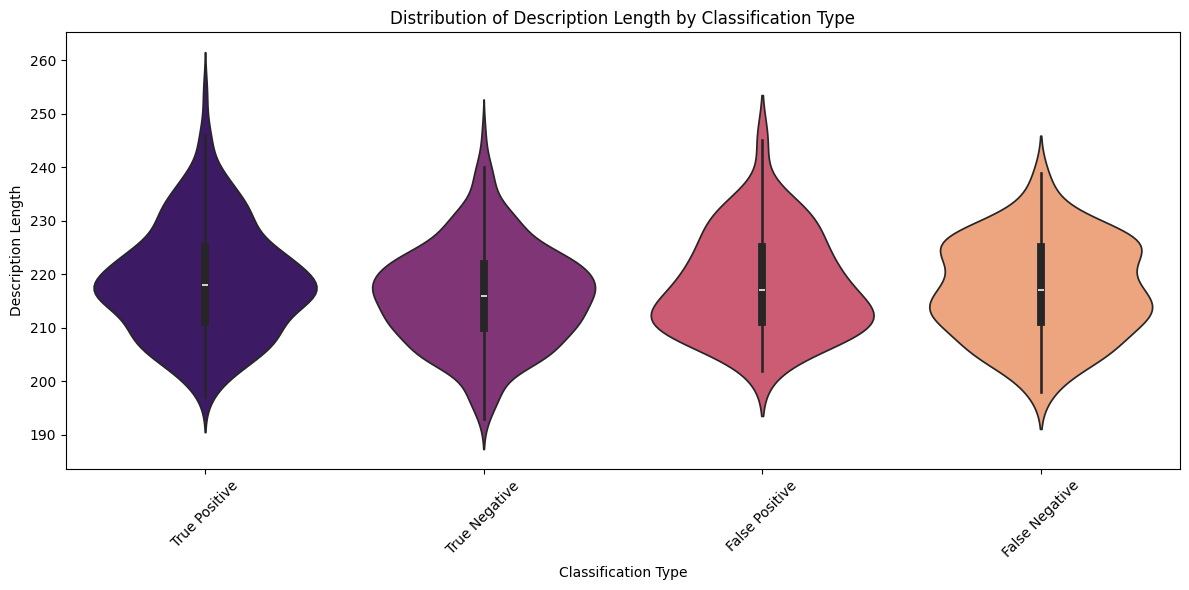

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for analysis with original features and classification labels
df_analysis = us_df.loc[X_test_all_extended.index, ['job_title_length', 'description_length']].copy()
df_analysis['actual'] = y_test_all_extended
df_analysis['predicted'] = y_pred_best_rf_all

# Assign classification type
def get_classification_type(row):
    if row['actual'] == 1 and row['predicted'] == 1:
        return 'True Positive'
    elif row['actual'] == 0 and row['predicted'] == 0:
        return 'True Negative'
    elif row['actual'] == 0 and row['predicted'] == 1:
        return 'False Positive'
    else:  # actual == 1 and predicted == 0
        return 'False Negative'

df_analysis['classification_type'] = df_analysis.apply(get_classification_type, axis=1)

# Order for plotting
order = ['True Positive', 'True Negative', 'False Positive', 'False Negative']

# Plot distribution of job_title_length
plt.figure(figsize=(12, 6))
sns.violinplot(x='classification_type', y='job_title_length', data=df_analysis, order=order, palette='viridis')
plt.title('Distribution of Job Title Length by Classification Type')
plt.xlabel('Classification Type')
plt.ylabel('Job Title Length')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot distribution of description_length
plt.figure(figsize=(12, 6))
sns.violinplot(x='classification_type', y='description_length', data=df_analysis, order=order, palette='magma')
plt.title('Distribution of Description Length by Classification Type')
plt.xlabel('Classification Type')
plt.ylabel('Description Length')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

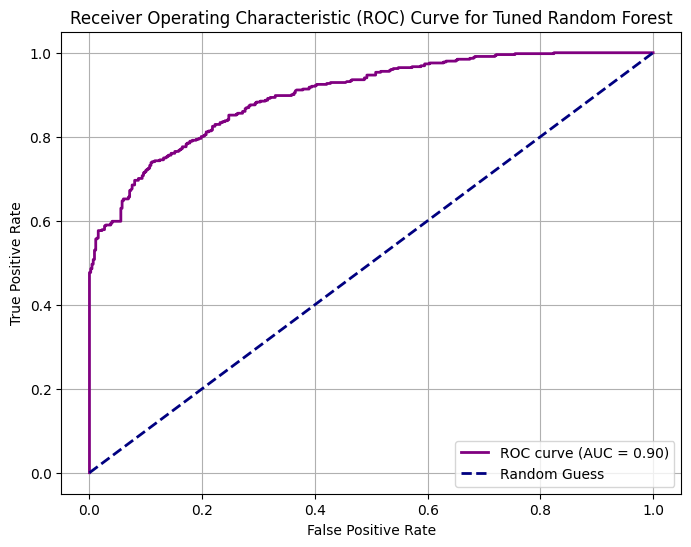

In [30]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_prob_best_rf_all = best_rf_model_all.predict_proba(X_test_all_extended)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_all_extended, y_prob_best_rf_all)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Tuned Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

<Figure size 800x600 with 0 Axes>

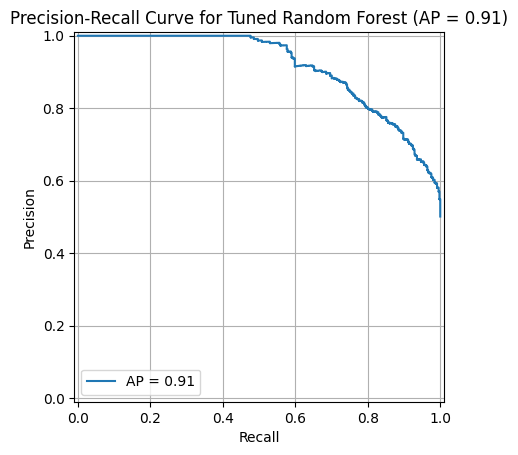

In [31]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, average_precision_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_prob_best_rf_all = best_rf_model_all.predict_proba(X_test_all_extended)[:, 1]

# Compute Precision-Recall curve and Average Precision Score
precision, recall, _ = precision_recall_curve(y_test_all_extended, y_prob_best_rf_all)
aps = average_precision_score(y_test_all_extended, y_prob_best_rf_all)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
disp = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=aps)
disp.plot()
plt.title(f'Precision-Recall Curve for Tuned Random Forest (AP = {aps:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

In [29]:
from sklearn.metrics import classification_report

# The classification report for the final tuned model is stored in `report_best_rf_all`
print('Tuned Random Forest Classification Report (with company_name and location):\n', report_best_rf_all)

Tuned Random Forest Classification Report (with company_name and location):
               precision    recall  f1-score   support

           0       0.77      0.89      0.83       449
           1       0.87      0.74      0.80       451

    accuracy                           0.81       900
   macro avg       0.82      0.81      0.81       900
weighted avg       0.82      0.81      0.81       900



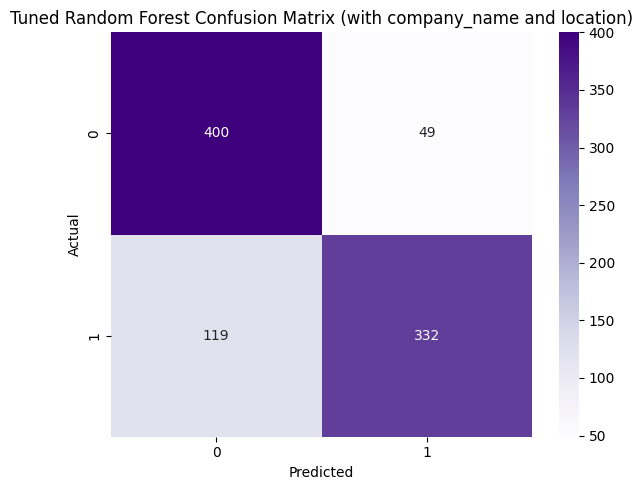

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# The confusion matrix for the final tuned model is stored in `cm_best_rf_all`
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_rf_all, annot=True, fmt='d', cmap='Purples')
plt.title('Tuned Random Forest Confusion Matrix (with company_name and location)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import classification_report

# The classification report for the final tuned model is stored in `report_best_rf_all`
print('Tuned Random Forest Classification Report (with company_name and location):\n', report_best_rf_all)

Tuned Random Forest Classification Report (with company_name and location):
               precision    recall  f1-score   support

           0       0.77      0.89      0.83       449
           1       0.87      0.74      0.80       451

    accuracy                           0.81       900
   macro avg       0.82      0.81      0.81       900
weighted avg       0.82      0.81      0.81       900



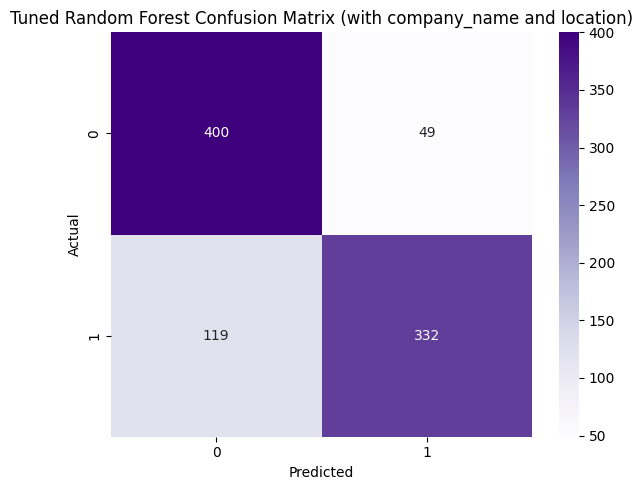

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# The confusion matrix for the final tuned model is stored in `cm_best_rf_all`
# The predictions are in `y_pred_best_rf_all` and the true labels in `y_test_all_extended`

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_rf_all, annot=True, fmt='d', cmap='Purples')
plt.title('Tuned Random Forest Confusion Matrix (with company_name and location)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Discussion and Conclusion

The above analysis provides several insights into the job posting data. We conducted data cleaning and transformation, converting date strings to datetime objects and engineering useful features such as average salary and text length metrics. A variety of visualizations were created to understand the distribution and relationships in data. Despite the limitations of the dataset, our exploratory data analysis and simple logistic regression predictor shed light on potential approaches for future workforce intelligence models.

Some merits of our approach include the dynamic file resolution for data loading and the usage of multiple visualization techniques to ensure a holistic view of the data. Future analysis could incorporate advanced natural language processing on the job descriptions and tech stacks, and experiment with more sophisticated models for salary prediction.

If you found this notebook useful, please upvote it. Your support is appreciated.